# SUBFASE 5: SVC clasico multihorizonte con validacion temporal robusta (BVG)

Objetivo de subfase:
- Entrenar y evaluar SVC clasico para h=1, h=5 y h=20 con validacion temporal robusta.
- Comparar kernels e hiperparametros.
- Comparar contra baselines obligatorios y seleccionar mejor modelo por horizonte.

Reglas metodologicas:
- Sin random split.
- Sin leakage (escalado dentro de pipeline y tuning solo en train).
- Dataset de entrada: data/processed/BVG_features_svc_master.csv.
- Validacion principal: walk-forward expanding window.


## Diseno experimental y configuracion walk-forward fija

Lineamientos usados para el grid SVC:
- Clasificacion financiera con SVM depende de kernel, C y gamma.
- Se prioriza un grid acotado pero informativo para evitar sobreajuste por busqueda excesiva.
- Se incluyen solo kernels linear, rbf y poly.

Rangos usados:
- C en escala logaritmica: [0.1, 1, 10, 50] para linear y rbf; [0.1, 1, 10] para poly.
- gamma: ['scale', 0.01, 0.1, 1] para rbf y ['scale', 0.1] para poly.
- degree: [2, 3] para poly.
- class_weight: [None, 'balanced'] para robustez ante desbalance.

Configuracion walk-forward usada:
- initial_train = 120, test_size = 30, step = 30


In [ ]:
# 2) Librerias
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC

from bvg_core.config import (
  DATA_MASTER_PATH, FECHA_COL_2, EMPRESA_COL
)

pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 320)
sns.set_theme(style='whitegrid')

In [ ]:
# 3) Carga del dataset de features de Subfase 4
df = pd.read_csv(DATA_MASTER_PATH)
df[FECHA_COL_2] = pd.to_datetime(df[FECHA_COL_2], errors='coerce')

print('Shape:', df.shape)
print('Rango fechas:', df[FECHA_COL_2].min(), '->', df[FECHA_COL_2].max())
print('Empresas:', sorted(df[EMPRESA_COL].dropna().unique().tolist()))
display(df.head())
display(df.dtypes)


Shape: (2841, 32)
Rango fechas: 2019-01-25 00:00:00 -> 2026-03-25 00:00:00
Empresas: ['BANCO GUAYAQUIL S.A.', 'CORPORACION FAVORITA C.A.']


,fecha,empresa,close_last,close_vwap,volume_shares_day,turnover_value_day,n_trades_day,ret_lag_1,ret_lag_2,ret_lag_3,mom_3,mom_5,mom_10,vol_5,vol_10,regime_vol_ratio,ma_5,ma_10,ma_gap,price_vs_ma10,rsi_14,turnover_log1p,volume_log1p,avg_trade_size_log1p,amihud_5,days_since_trade,ret_fwd_h1,ret_fwd_h5,ret_fwd_h20,target_up_h1,target_up_h5,target_up_h20
0,2019-02-13,BANCO GUAYAQUIL S.A.,0.97,0.97,35000.0,33950.0,1.0,0.040822,-0.040822,0.000000,3.469447e-17,4.082199e-02,0.030459,0.034154,0.024103,1.416994,0.984,0.975,0.009,0.025641,62.452022,10.432674,10.463132,10.463132,0.000016,1.0,0.030459,0.030459,-0.010363,1.0,1.0,0.0
1,2019-02-19,BANCO GUAYAQUIL S.A.,1.00,1.00,2046.0,2046.0,6.0,-0.030459,0.040822,-0.040822,-3.045921e-02,1.036279e-02,0.010363,0.038424,0.026100,1.472155,0.986,0.976,0.010,-0.006148,52.665650,7.624131,7.624131,5.834811,0.000016,6.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
2,2019-02-20,BANCO GUAYAQUIL S.A.,1.00,1.00,1500.0,1500.0,1.0,0.030459,-0.030459,0.040822,4.082199e-02,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.979,0.007,0.021450,59.078190,7.313887,7.313887,7.313887,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
3,2019-02-21,BANCO GUAYAQUIL S.A.,1.00,1.00,591494.0,591494.0,14.0,0.000000,0.030459,-0.030459,7.979728e-17,1.144917e-16,0.030459,0.036015,0.027627,1.303608,0.986,0.982,0.004,0.018330,59.078190,13.290409,13.290409,10.651373,0.000019,1.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0
4,2019-02-26,BANCO GUAYAQUIL S.A.,1.00,1.00,2771.0,2771.0,1.0,0.000000,0.000000,0.030459,3.045921e-02,4.082199e-02,0.030459,0.028234,0.027627,1.021964,0.994,0.985,0.009,0.015228,57.100950,7.927324,7.927324,7.927324,0.000003,5.0,0.000000,0.000000,-0.051293,0.0,0.0,0.0


fecha                   datetime64[us]
empresa                            str
close_last                     float64
close_vwap                     float64
volume_shares_day              float64
turnover_value_day             float64
n_trades_day                   float64
ret_lag_1                      float64
ret_lag_2                      float64
ret_lag_3                      float64
mom_3                          float64
mom_5                          float64
mom_10                         float64
vol_5                          float64
vol_10                         float64
regime_vol_ratio               float64
ma_5                           float64
ma_10                          float64
ma_gap                         float64
price_vs_ma10                  float64
rsi_14                         float64
turnover_log1p                 float64
volume_log1p                   float64
avg_trade_size_log1p           float64
amihud_5                       float64
days_since_trade         

In [5]:
# 4) Configuracion de features, targets y grids
FEATURE_COLS = [
    'ret_lag_1', 'ret_lag_2', 'ret_lag_3',
    'mom_3', 'mom_5', 'mom_10',
    'vol_5', 'vol_10', 'regime_vol_ratio',
    'ma_5', 'ma_10', 'ma_gap', 'price_vs_ma10',
    'rsi_14',
    'turnover_log1p', 'volume_log1p',
    'avg_trade_size_log1p',
    'amihud_5', 'days_since_trade'
]

TARGET_MAP = {
    'h1': 'target_up_h1',
    'h5': 'target_up_h5',
    'h20': 'target_up_h20'
}

KERNELS = ['linear', 'rbf', 'poly']

KERNEL_GRIDS = {
    'linear': {
        'svc__kernel': ['linear'],
        'svc__C': [0.1, 1, 10, 50],
        'svc__class_weight': [None, 'balanced']
    },
    'rbf': {
        'svc__kernel': ['rbf'],
        'svc__C': [0.1, 1, 10, 50],
        'svc__gamma': ['scale', 0.01, 0.1, 1],
        'svc__class_weight': [None, 'balanced']
    },
    'poly': {
        'svc__kernel': ['poly'],
        'svc__C': [0.1, 1, 10],
        'svc__degree': [2, 3],
        'svc__gamma': ['scale', 0.1],
        'svc__coef0': [0.0, 0.5],
        'svc__class_weight': [None, 'balanced']
    }
}

print('Numero de features:', len(FEATURE_COLS))
print('Horizontes:', list(TARGET_MAP.keys()))
print('Kernels:', KERNELS)

Numero de features: 19
Horizontes: ['h1', 'h5', 'h20']
Kernels: ['linear', 'rbf', 'poly']


In [ ]:
# 5) Utilidades de evaluacion temporal (walk-forward fijo)
WF_INITIAL_TRAIN = 120
WF_TEST_SIZE = 30
WF_STEP = 30

def safe_tscv_splits(n_train):
    # Mantiene CV temporal viable en muestras chicas
    return max(3, min(5, n_train // 80))

def make_valid_tscv(y_train):
    # Evita folds de entrenamiento con una sola clase (causa FitFailed en SVC)
    y = pd.Series(y_train).reset_index(drop=True)
    max_splits = min(safe_tscv_splits(len(y)), len(y) - 1)

    for n_splits in range(max_splits, 1, -1):
        tscv = TimeSeriesSplit(n_splits=n_splits)
        is_valid = True

        for tr_idx, _ in tscv.split(np.arange(len(y))):
            if y.iloc[tr_idx].nunique() < 2:
                is_valid = False
                break

        if is_valid:
            return tscv

    return None

def default_kernel_params(kernel_name):
    defaults = {
        'linear': {'kernel': 'linear', 'C': 1, 'class_weight': 'balanced'},
        'rbf': {'kernel': 'rbf', 'C': 1, 'gamma': 'scale', 'class_weight': 'balanced'},
        'poly': {'kernel': 'poly', 'C': 1, 'degree': 2, 'gamma': 'scale', 'coef0': 0.0, 'class_weight': 'balanced'}
    }
    return defaults[kernel_name].copy()

def cls_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    return {
        'accuracy': float(acc),
        'directional_accuracy': float(acc),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0))
    }

def baseline_majority(y_train, n_test):
    maj = int(pd.Series(y_train).mode().iloc[0])
    return np.full(n_test, maj, dtype=int)

def baseline_sign_prev(test_df):
    return (test_df['ret_lag_1'].values > 0).astype(int)

def train_kernel_with_grid(X_train, y_train, kernel_name):
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('svc', SVC())
    ])

    tscv = make_valid_tscv(y_train)
    if tscv is None:
        return None

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=KERNEL_GRIDS[kernel_name],
        scoring='f1',
        cv=tscv,
        n_jobs=-1,
        error_score=np.nan
    )
    gs.fit(X_train, y_train)
    return gs

def strip_svc_prefix(params):
    clean = {}
    for k, v in params.items():
        if k.startswith('svc__'):
            clean[k.replace('svc__', '')] = v
    return clean

def fit_predict_with_fixed_params(train_df, test_df, target_col, svc_params):
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('svc', SVC(**svc_params))
    ])
    X_train = train_df[FEATURE_COLS]
    y_train = train_df[target_col].astype(int)
    X_test = test_df[FEATURE_COLS]
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    return y_pred

def run_walkforward_case(d_case, target_col, empresa, h_name):
    d = d_case.sort_values('fecha').reset_index(drop=True).copy()
    n = len(d)

    initial_train = WF_INITIAL_TRAIN
    test_size = WF_TEST_SIZE
    step = WF_STEP

    if n < (initial_train + test_size + 5):
        return pd.DataFrame(), pd.DataFrame()

    # Tuning temporal interno solo en bloque inicial (eficiente y sin leakage)
    init_train = d.iloc[:initial_train].copy()
    X_init = init_train[FEATURE_COLS]
    y_init = init_train[target_col].astype(int)

    tuned_params = {}
    tuned_scores = {}
    for kernel_name in KERNELS:
        gs = train_kernel_with_grid(X_init, y_init, kernel_name)

        if gs is None:
            tuned_params[kernel_name] = default_kernel_params(kernel_name)
            tuned_scores[kernel_name] = np.nan
        else:
            tuned_params[kernel_name] = strip_svc_prefix(gs.best_params_)
            tuned_scores[kernel_name] = float(gs.best_score_)

    rows = []
    preds = []
    window_id = 0
    train_end = initial_train

    while (train_end + test_size) <= n:
        train = d.iloc[:train_end].copy()
        test = d.iloc[train_end:train_end + test_size].copy()

        y_train = train[target_col].astype(int)
        y_test = test[target_col].astype(int)

        y_pred_maj = baseline_majority(y_train.values, len(y_test))
        rows.append({
            'empresa': empresa, 'horizonte': h_name, 'window_id': window_id,
            'model': 'baseline_majority', 'kernel': 'baseline', 'best_cv_f1': np.nan, 'best_params': '',
            'n_train': len(train), 'n_test': len(test), **cls_metrics(y_test, y_pred_maj)
        })

        y_pred_sign = baseline_sign_prev(test)
        rows.append({
            'empresa': empresa, 'horizonte': h_name, 'window_id': window_id,
            'model': 'baseline_sign_prev', 'kernel': 'baseline', 'best_cv_f1': np.nan, 'best_params': '',
            'n_train': len(train), 'n_test': len(test), **cls_metrics(y_test, y_pred_sign)
        })

        for kernel_name in KERNELS:
            params = tuned_params[kernel_name]
            y_pred = fit_predict_with_fixed_params(train, test, target_col, params)
            m = cls_metrics(y_test, y_pred)
            rows.append({
                'empresa': empresa, 'horizonte': h_name, 'window_id': window_id,
                'model': f'svc_{kernel_name}', 'kernel': kernel_name,
                'best_cv_f1': tuned_scores[kernel_name], 'best_params': str(params),
                'n_train': len(train), 'n_test': len(test), **m
            })

            for i, (_, r) in enumerate(test.reset_index(drop=True).iterrows()):
                preds.append({
                    'empresa': empresa, 'horizonte': h_name, 'window_id': window_id,
                    'fecha': r['fecha'], 'model': f'svc_{kernel_name}',
                    'y_true': int(y_test.iloc[i]), 'y_pred': int(y_pred[i])
                })

        window_id += 1
        train_end += step

    return pd.DataFrame(rows), pd.DataFrame(preds)


In [ ]:
# 6) Ejecucion integrada con configuracion walk-forward fija
wf_rows = []
wf_preds = []

min_required = WF_INITIAL_TRAIN + WF_TEST_SIZE + 5

for empresa in sorted(df['empresa'].dropna().unique()):
    d_emp = df[df['empresa'] == empresa].copy().sort_values('fecha').reset_index(drop=True)

    for h_name, target_col in TARGET_MAP.items():
        d_case = d_emp.dropna(subset=FEATURE_COLS + [target_col]).copy().sort_values('fecha').reset_index(drop=True)

        if len(d_case) < min_required:
            print(f"Salto {empresa} {h_name}: muestra insuficiente ({len(d_case)}).")
            continue

        w_res, w_pred = run_walkforward_case(
            d_case=d_case,
            target_col=target_col,
            empresa=empresa,
            h_name=h_name
        )

        if not w_res.empty:
            wf_rows.append(w_res)
        if not w_pred.empty:
            wf_preds.append(w_pred)

wf_df = pd.concat(wf_rows, ignore_index=True) if wf_rows else pd.DataFrame()
wf_pred_df = pd.concat(wf_preds, ignore_index=True) if wf_preds else pd.DataFrame()

if wf_df.empty:
    raise ValueError('No se obtuvieron resultados walk-forward. Revisa muestra y parametros.')

print('Walk-forward rows:', wf_df.shape)
if not wf_df.empty:
    display(wf_df.sort_values(['empresa', 'horizonte', 'window_id', 'f1'], ascending=[True, True, True, False]).head(20))

Walk-forward rows: (1280, 14)


,empresa,horizonte,window_id,model,kernel,best_cv_f1,best_params,n_train,n_test,accuracy,directional_accuracy,precision,recall,f1
4,BANCO GUAYAQUIL S.A.,h1,0,svc_poly,poly,0.358100,"{'C': 10, 'class_weight': None, 'coef0': 0.5, ...",120,30,0.666667,0.666667,0.285714,1.000000,0.444444
2,BANCO GUAYAQUIL S.A.,h1,0,svc_linear,linear,0.293603,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",120,30,0.766667,0.766667,0.200000,0.250000,0.222222
3,BANCO GUAYAQUIL S.A.,h1,0,svc_rbf,rbf,0.360195,"{'C': 1, 'class_weight': 'balanced', 'gamma': ...",120,30,0.466667,0.466667,0.125000,0.500000,0.200000
0,BANCO GUAYAQUIL S.A.,h1,0,baseline_majority,baseline,NaN,,120,30,0.866667,0.866667,0.000000,0.000000,0.000000
1,BANCO GUAYAQUIL S.A.,h1,0,baseline_sign_prev,baseline,NaN,,120,30,0.733333,0.733333,0.000000,0.000000,0.000000
7,BANCO GUAYAQUIL S.A.,h1,1,svc_linear,linear,0.293603,"{'C': 1, 'class_weight': 'balanced', 'kernel':...",150,30,0.566667,0.566667,0.352941,0.750000,0.480000
8,BANCO GUAYAQUIL S.A.,h1,1,svc_rbf,rbf,0.360195,"{'C': 1, 'class_weight': 'balanced', 'gamma': ...",150,30,0.700000,0.700000,0.444444,0.500000,0.470588
9,BANCO GUAYAQUIL S.A.,h1,1,svc_poly,poly,0.358100,"{'C': 10, 'class_weight': None, 'coef0': 0.5, ...",150,30,0.633333,0.633333,0.333333,0.375000,0.352941
6,BANCO GUAYAQUIL S.A.,h1,1,baseline_sign_prev,baseline,NaN,,150,30,0.533333,0.533333,0.125000,0.125000,0.125000
5,BANCO GUAYAQUIL S.A.,h1,1,baseline_majority,baseline,NaN,,150,30,0.733333,0.733333,0.000000,0.000000,0.000000


In [8]:
# 7) Resumen robusto (walk-forward) y mejor modelo por empresa-horizonte
if wf_df.empty:
    raise ValueError('No hay resultados walk-forward. Revisa tamano de muestra y configuracion.')

wf_summary = (
    wf_df.groupby(['empresa', 'horizonte', 'model', 'kernel']).agg(
        n_windows=('window_id', 'count'),
        acc_mean=('accuracy', 'mean'),
        acc_std=('accuracy', 'std'),
        f1_mean=('f1', 'mean'),
        f1_std=('f1', 'std'),
        dir_acc_mean=('directional_accuracy', 'mean'),
        cv_f1_mean=('best_cv_f1', 'mean')
    ).reset_index()
)

base_summary = wf_summary[wf_summary['kernel'] == 'baseline'].copy()
svc_summary = wf_summary[wf_summary['kernel'] != 'baseline'].copy()

best_baseline_case = (
    base_summary.sort_values(['empresa', 'horizonte', 'f1_mean', 'acc_mean'], ascending=[True, True, False, False])
    .groupby(['empresa', 'horizonte'], as_index=False)
    .first()[['empresa', 'horizonte', 'model', 'f1_mean', 'acc_mean']]
    .rename(columns={
        'model': 'best_baseline_model',
        'f1_mean': 'baseline_f1_mean',
        'acc_mean': 'baseline_acc_mean'
    })
)

best_svc_case = (
    svc_summary.sort_values(['empresa', 'horizonte', 'f1_mean', 'acc_mean'], ascending=[True, True, False, False])
    .groupby(['empresa', 'horizonte'], as_index=False)
    .first()
)

best_svc_case = best_svc_case.merge(best_baseline_case, on=['empresa', 'horizonte'], how='left')
best_svc_case['delta_f1_vs_baseline'] = best_svc_case['f1_mean'] - best_svc_case['baseline_f1_mean']
best_svc_case['delta_acc_vs_baseline'] = best_svc_case['acc_mean'] - best_svc_case['baseline_acc_mean']

print('Mejor SVC por empresa y horizonte (criterio robusto walk-forward):')
display(best_svc_case[['empresa', 'horizonte', 'model', 'kernel', 'n_windows', 'f1_mean', 'f1_std', 'acc_mean', 'acc_std', 'baseline_f1_mean', 'baseline_acc_mean', 'delta_f1_vs_baseline', 'delta_acc_vs_baseline']])

Mejor SVC por empresa y horizonte (criterio robusto walk-forward):


,empresa,horizonte,model,kernel,n_windows,f1_mean,f1_std,acc_mean,acc_std,baseline_f1_mean,baseline_acc_mean,delta_f1_vs_baseline,delta_acc_vs_baseline
0,BANCO GUAYAQUIL S.A.,h1,svc_linear,linear,34,0.396396,0.200249,0.604902,0.109524,0.331630,0.571569,0.064766,0.033333
1,BANCO GUAYAQUIL S.A.,h20,svc_rbf,rbf,33,0.392861,0.331449,0.580808,0.258337,0.356817,0.510101,0.036044,0.070707
2,BANCO GUAYAQUIL S.A.,h5,svc_linear,linear,34,0.434327,0.260980,0.590196,0.175336,0.349524,0.526471,0.084802,0.063725
3,CORPORACION FAVORITA C.A.,h1,svc_linear,linear,52,0.371191,0.171561,0.503205,0.109914,0.294472,0.573077,0.076719,-0.069872
4,CORPORACION FAVORITA C.A.,h20,svc_rbf,rbf,51,0.442095,0.333657,0.530065,0.266855,0.261946,0.522222,0.180149,0.007843
5,CORPORACION FAVORITA C.A.,h5,svc_rbf,rbf,52,0.385034,0.242280,0.575641,0.164113,0.315176,0.576923,0.069858,-0.001282


In [9]:
# 8) Ranking de horizontes + mejor kernel por horizonte
cmp_rows = []

for _, r in best_svc_case.iterrows():
    empresa = r['empresa']
    horizonte = r['horizonte']
    svc_model = r['model']
    base_model = r['best_baseline_model']

    w_svc = wf_df[(wf_df['empresa'] == empresa) & (wf_df['horizonte'] == horizonte) & (wf_df['model'] == svc_model)][['window_id', 'accuracy', 'f1']]
    w_base = wf_df[(wf_df['empresa'] == empresa) & (wf_df['horizonte'] == horizonte) & (wf_df['model'] == base_model)][['window_id', 'accuracy', 'f1']]

    m = w_svc.merge(w_base, on='window_id', suffixes=('_svc', '_base'))
    if m.empty:
        continue

    cmp_rows.append({
        'empresa': empresa,
        'horizonte': horizonte,
        'svc_model': svc_model,
        'baseline_model': base_model,
        'pct_windows_f1_better': float((m['f1_svc'] > m['f1_base']).mean() * 100),
        'pct_windows_acc_better': float((m['accuracy_svc'] > m['accuracy_base']).mean() * 100)
    })

case_cmp_df = pd.DataFrame(cmp_rows)
best_svc_case = best_svc_case.merge(
    case_cmp_df,
    left_on=['empresa', 'horizonte', 'model', 'best_baseline_model'],
    right_on=['empresa', 'horizonte', 'svc_model', 'baseline_model'],
    how='left'
 )

best_svc_case['selection_score'] = (
    best_svc_case['delta_f1_vs_baseline'] * 100
    + best_svc_case['delta_acc_vs_baseline'] * 60
    + best_svc_case['pct_windows_f1_better'].fillna(0) * 0.2
    + best_svc_case['pct_windows_acc_better'].fillna(0) * 0.1
    - best_svc_case['f1_std'].fillna(0) * 30
    - best_svc_case['acc_std'].fillna(0) * 20
)

horizon_kernel_summary = (
    svc_summary.groupby(['horizonte', 'kernel']).agg(
        n_cases=('model', 'count'),
        f1_mean=('f1_mean', 'mean'),
        f1_std_mean=('f1_std', 'mean'),
        acc_mean=('acc_mean', 'mean'),
        acc_std_mean=('acc_std', 'mean')
    ).reset_index()
)

best_kernel_by_h = (
    horizon_kernel_summary.sort_values(['horizonte', 'f1_mean', 'acc_mean'], ascending=[True, False, False])
    .groupby('horizonte', as_index=False)
    .first()
)

# Regla explicita para horizonte unico global
n_empresas_total = int(best_svc_case['empresa'].nunique())

horizon_global_summary = (
    best_svc_case.groupby('horizonte', as_index=False).agg(
        n_empresas=('empresa', 'nunique'),
        selection_score_mean=('selection_score', 'mean'),
        selection_score_min=('selection_score', 'min'),
        delta_f1_mean=('delta_f1_vs_baseline', 'mean'),
        delta_f1_min=('delta_f1_vs_baseline', 'min'),
        delta_acc_mean=('delta_acc_vs_baseline', 'mean'),
        f1_mean_avg=('f1_mean', 'mean'),
        acc_mean_avg=('acc_mean', 'mean'),
        f1_std_avg=('f1_std', 'mean'),
        acc_std_avg=('acc_std', 'mean')
    ).reset_index()
)

horizon_global_summary['rule_all_empresas_covered'] = horizon_global_summary['n_empresas'] == n_empresas_total
horizon_global_summary['rule_min_delta_f1_positive'] = horizon_global_summary['delta_f1_min'] > 0
horizon_global_summary['rule_min_selection_score_positive'] = horizon_global_summary['selection_score_min'] > 0
horizon_global_summary['eligible_global'] = (
    horizon_global_summary['rule_all_empresas_covered']
    & horizon_global_summary['rule_min_delta_f1_positive']
    & horizon_global_summary['rule_min_selection_score_positive']
)

eligible_global = horizon_global_summary[horizon_global_summary['eligible_global']].copy()

if not eligible_global.empty:
    global_horizon_decision_df = (
        eligible_global.sort_values(
            ['selection_score_mean', 'delta_f1_mean', 'f1_mean_avg', 'acc_mean_avg'],
            ascending=[False, False, False, False]
        )
        .head(1)
        .copy()
    )
    global_horizon_decision_df['decision_type'] = 'global_rule_strict'
    global_horizon_decision_df['decision_reason'] = (
        'Cumple cobertura total y mejora minima positiva en F1 y selection_score para todas las empresas.'
    )
else:
    global_horizon_decision_df = (
        horizon_global_summary.sort_values(
            ['selection_score_mean', 'delta_f1_mean', 'f1_mean_avg', 'acc_mean_avg'],
            ascending=[False, False, False, False]
        )
        .head(1)
        .copy()
    )
    global_horizon_decision_df['decision_type'] = 'global_rule_fallback'
    global_horizon_decision_df['decision_reason'] = (
        'No hubo horizonte que cumpla la regla estricta; se elige el mejor score promedio global.'
    )

global_horizon_selected = global_horizon_decision_df.iloc[0]['horizonte']

print('Comparacion robusta vs baseline por empresa-horizonte:')
display(best_svc_case[['empresa', 'horizonte', 'model', 'kernel', 'f1_mean', 'acc_mean', 'delta_f1_vs_baseline', 'delta_acc_vs_baseline', 'pct_windows_f1_better', 'pct_windows_acc_better', 'selection_score']])

print('Kernel ganador por horizonte (agregado):')
display(best_kernel_by_h)

print('Resumen de decision global por horizonte (regla explicita):')
display(
    horizon_global_summary.sort_values(
        ['eligible_global', 'selection_score_mean', 'delta_f1_mean', 'f1_mean_avg', 'acc_mean_avg'],
        ascending=[False, False, False, False, False]
    )
)

print('Decision global final de horizonte unico:')
display(global_horizon_decision_df[['horizonte', 'decision_type', 'selection_score_mean', 'delta_f1_mean', 'f1_mean_avg', 'acc_mean_avg', 'decision_reason']])
print('Horizonte global seleccionado:', global_horizon_selected)

Comparacion robusta vs baseline por empresa-horizonte:


,empresa,horizonte,model,kernel,f1_mean,acc_mean,delta_f1_vs_baseline,delta_acc_vs_baseline,pct_windows_f1_better,pct_windows_acc_better,selection_score
0,BANCO GUAYAQUIL S.A.,h1,svc_linear,linear,0.396396,0.604902,0.064766,0.033333,67.647059,61.764706,19.984501
1,BANCO GUAYAQUIL S.A.,h20,svc_rbf,rbf,0.392861,0.580808,0.036044,0.070707,48.484848,54.545455,7.888119
2,BANCO GUAYAQUIL S.A.,h5,svc_linear,linear,0.434327,0.590196,0.084802,0.063725,67.647059,70.588235,21.555899
3,CORPORACION FAVORITA C.A.,h1,svc_linear,linear,0.371191,0.503205,0.076719,-0.069872,67.307692,32.692308,12.865210
4,CORPORACION FAVORITA C.A.,h20,svc_rbf,rbf,0.442095,0.530065,0.180149,0.007843,66.666667,49.019608,21.373933
5,CORPORACION FAVORITA C.A.,h5,svc_rbf,rbf,0.385034,0.575641,0.069858,-0.001282,53.846154,50.000000,12.127434


Kernel ganador por horizonte (agregado):


,horizonte,kernel,n_cases,f1_mean,f1_std_mean,acc_mean,acc_std_mean
0,h1,linear,2,0.383793,0.185905,0.554054,0.109719
1,h20,rbf,2,0.417478,0.332553,0.555437,0.262596
2,h5,rbf,2,0.391342,0.257556,0.573605,0.170452


Resumen de decision global por horizonte (regla explicita):


,index,horizonte,n_empresas,selection_score_mean,selection_score_min,delta_f1_mean,delta_f1_min,delta_acc_mean,f1_mean_avg,acc_mean_avg,f1_std_avg,acc_std_avg,rule_all_empresas_covered,rule_min_delta_f1_positive,rule_min_selection_score_positive,eligible_global
2,2,h5,2,16.841667,12.127434,0.077330,0.069858,0.031222,0.409680,0.582919,0.251630,0.169725,True,True,True,True
0,0,h1,2,16.424855,12.865210,0.070742,0.064766,-0.018269,0.383793,0.554054,0.185905,0.109719,True,True,True,True
1,1,h20,2,14.631026,7.888119,0.108096,0.036044,0.039275,0.417478,0.555437,0.332553,0.262596,True,True,True,True


Decision global final de horizonte unico:


,horizonte,decision_type,selection_score_mean,delta_f1_mean,f1_mean_avg,acc_mean_avg,decision_reason
2,h5,global_rule_strict,16.841667,0.07733,0.40968,0.582919,Cumple cobertura total y mejora minima positiv...


Horizonte global seleccionado: h5


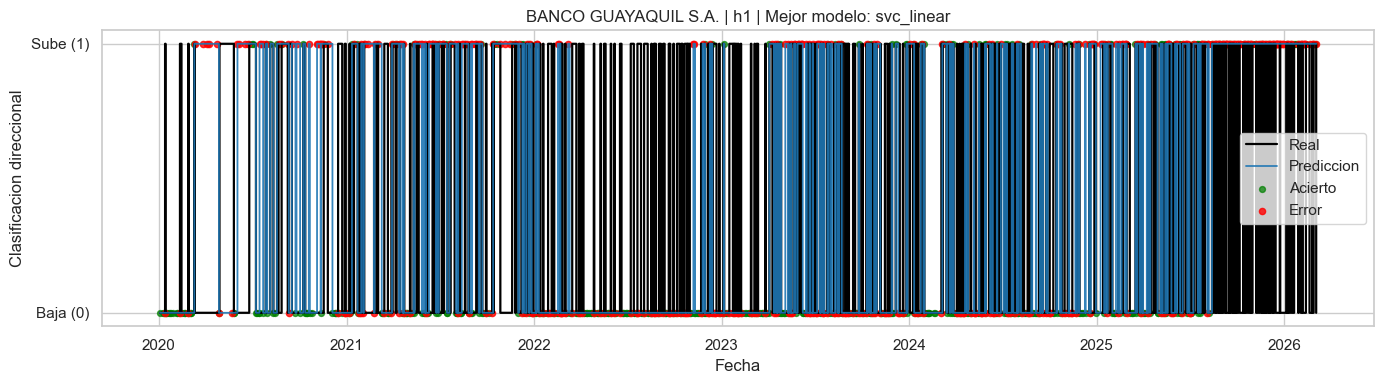

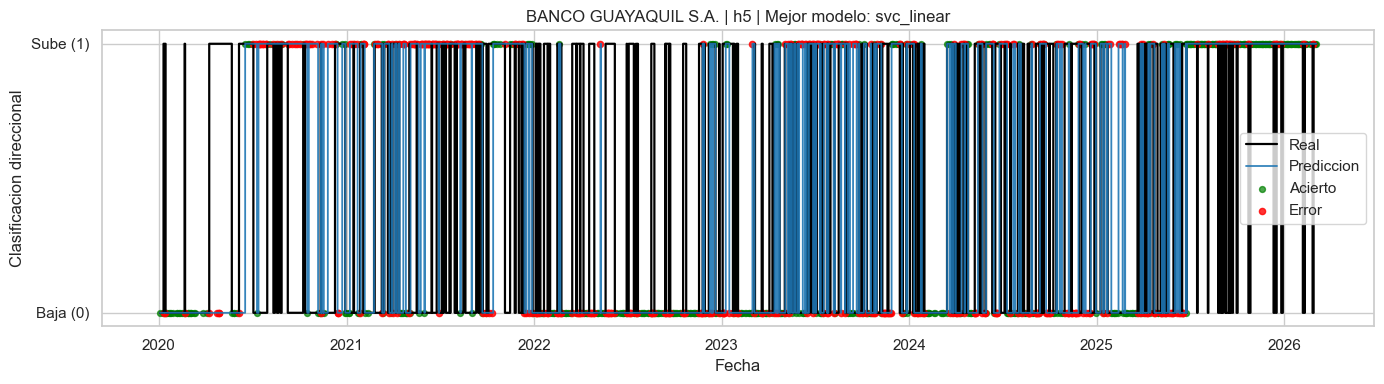

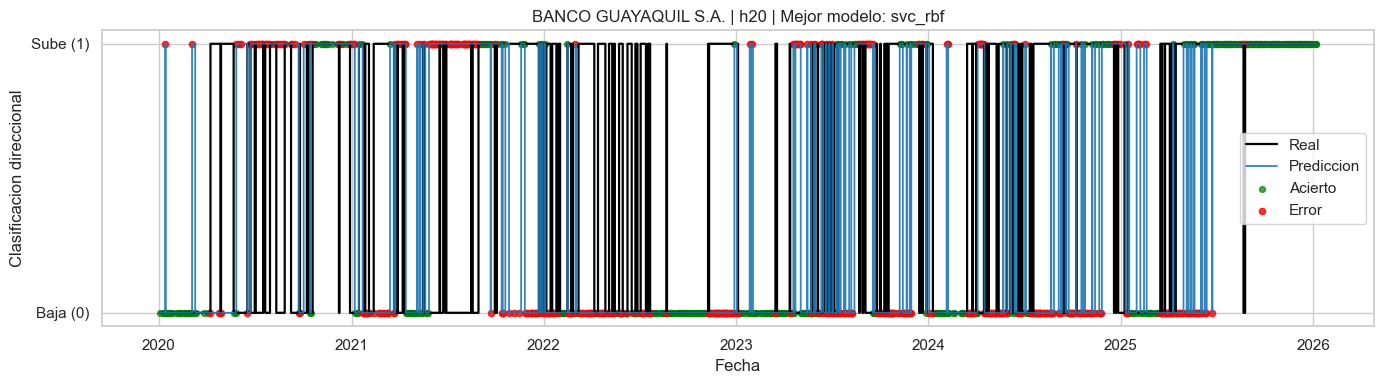

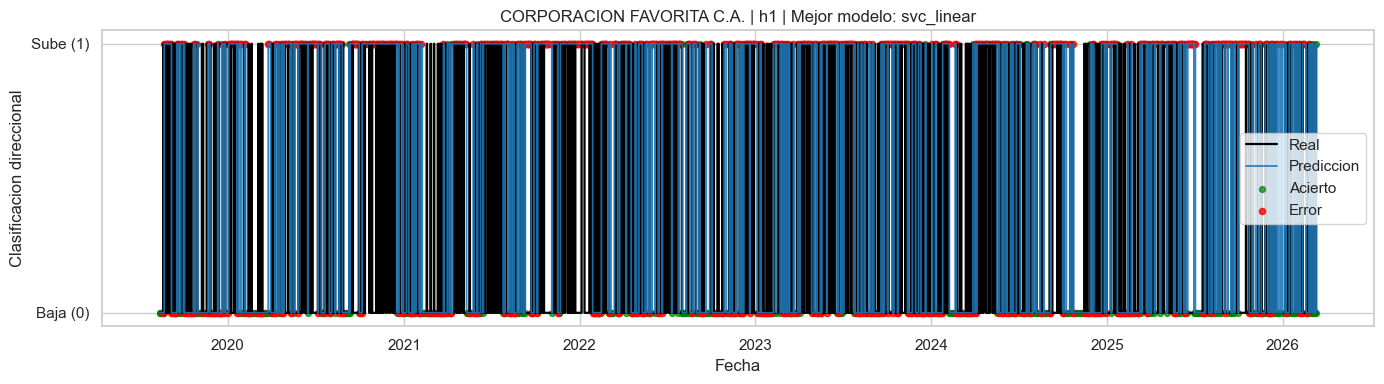

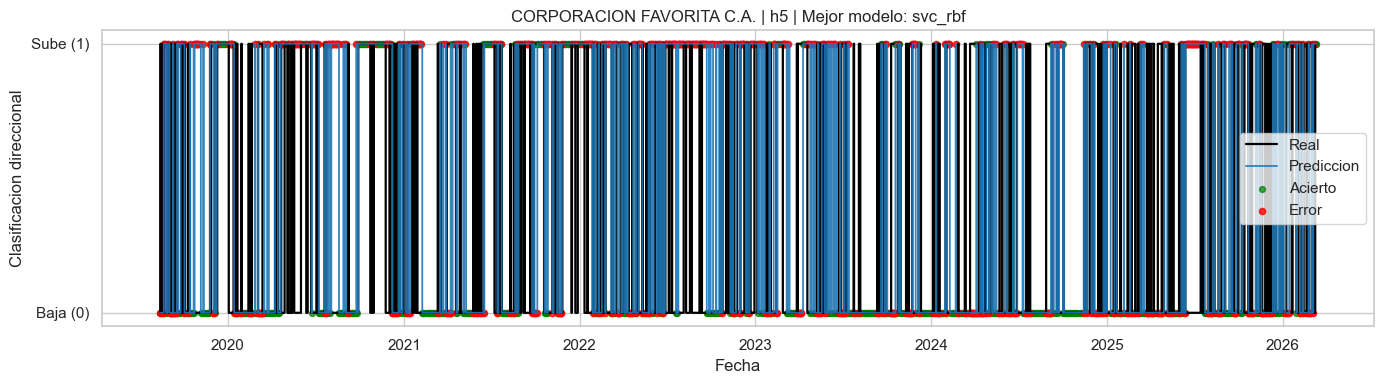

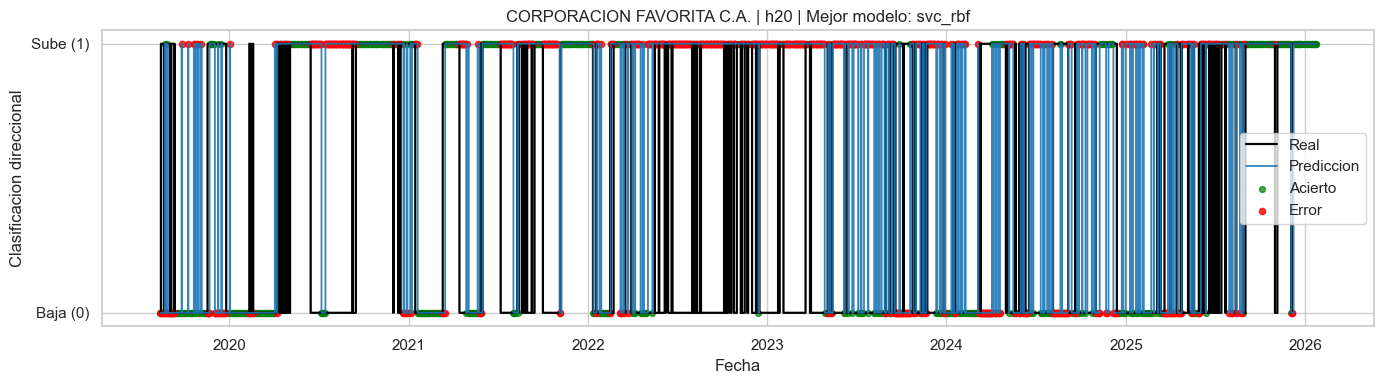

In [10]:
# 9) Grafico comparativo por horizonte y empresa (prediccion vs real, mejor modelo del horizonte)
if wf_pred_df.empty:
    raise ValueError('No hay predicciones walk-forward para graficar.')

for empresa in sorted(best_svc_case['empresa'].unique()):
    for horizonte in ['h1', 'h5', 'h20']:
        sel = best_svc_case[(best_svc_case['empresa'] == empresa) & (best_svc_case['horizonte'] == horizonte)]
        if sel.empty:
            continue

        model_name = sel.iloc[0]['model']
        p = wf_pred_df[
            (wf_pred_df['empresa'] == empresa) &
            (wf_pred_df['horizonte'] == horizonte) &
            (wf_pred_df['model'] == model_name)
        ].copy().sort_values('fecha')

        if p.empty:
            continue

        p = p.drop_duplicates(subset=['fecha'], keep='last')
        p['acierto'] = (p['y_true'] == p['y_pred']).astype(int)

        plt.figure(figsize=(14, 4))
        plt.plot(p['fecha'], p['y_true'], drawstyle='steps-post', linewidth=1.6, label='Real', color='black')
        plt.plot(p['fecha'], p['y_pred'], drawstyle='steps-post', linewidth=1.3, label='Prediccion', color='tab:blue', alpha=0.9)

        ok = p[p['acierto'] == 1]
        err = p[p['acierto'] == 0]
        if not ok.empty:
            plt.scatter(ok['fecha'], ok['y_pred'], color='green', s=18, alpha=0.7, label='Acierto')
        if not err.empty:
            plt.scatter(err['fecha'], err['y_pred'], color='red', s=20, alpha=0.8, label='Error')

        plt.yticks([0, 1], ['Baja (0)', 'Sube (1)'])
        plt.title(f'{empresa} | {horizonte} | Mejor modelo: {model_name}')
        plt.xlabel('Fecha')
        plt.ylabel('Clasificacion direccional')
        plt.legend(loc='best')
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

In [11]:
# 10) Exportacion de resultados de Subfase 5 (solo walk-forward)
if wf_df.empty:
    raise ValueError('No hay resultados walk-forward para exportar.')

output_dir = Path('../results/fase3_modelado_clasico/subfase5')
output_dir.mkdir(parents=True, exist_ok=True)

wf_df.to_csv(output_dir / 'BVG_subfase5_walkforward_resultados_ventana.csv', index=False)
wf_pred_df.to_csv(output_dir / 'BVG_subfase5_walkforward_predicciones.csv', index=False)
wf_summary.to_csv(output_dir / 'BVG_subfase5_walkforward_resumen.csv', index=False)
best_svc_case.to_csv(output_dir / 'BVG_subfase5_best_model_por_empresa_horizonte.csv', index=False)
horizon_kernel_summary.to_csv(output_dir / 'BVG_subfase5_resumen_kernel_horizonte.csv', index=False)
best_kernel_by_h.to_csv(output_dir / 'BVG_subfase5_best_kernel_por_horizonte.csv', index=False)
horizon_global_summary.to_csv(output_dir / 'BVG_subfase5_horizonte_decision_global_resumen.csv', index=False)
global_horizon_decision_df.to_csv(output_dir / 'BVG_subfase5_horizonte_decision_global.csv', index=False)

horizonte_ganador_por_empresa = (
    best_svc_case.sort_values(
        ['empresa', 'selection_score', 'delta_f1_vs_baseline', 'f1_mean', 'acc_mean'],
        ascending=[True, False, False, False, False]
    )
    .groupby('empresa', as_index=False)
    .first()
)
horizonte_ganador_por_empresa.to_csv(output_dir / 'BVG_subfase5_horizonte_ganador_por_empresa.csv', index=False)

print(f'Archivos exportados en {output_dir.as_posix()}/:')
print('- BVG_subfase5_walkforward_resultados_ventana.csv')
print('- BVG_subfase5_walkforward_predicciones.csv')
print('- BVG_subfase5_walkforward_resumen.csv')
print('- BVG_subfase5_best_model_por_empresa_horizonte.csv')
print('- BVG_subfase5_resumen_kernel_horizonte.csv')
print('- BVG_subfase5_best_kernel_por_horizonte.csv')
print('- BVG_subfase5_horizonte_decision_global_resumen.csv')
print('- BVG_subfase5_horizonte_decision_global.csv')
print('- BVG_subfase5_horizonte_ganador_por_empresa.csv')


Archivos exportados en ../results/fase3_modelado_clasico/subfase5/:
- BVG_subfase5_walkforward_resultados_ventana.csv
- BVG_subfase5_walkforward_predicciones.csv
- BVG_subfase5_walkforward_resumen.csv
- BVG_subfase5_best_model_por_empresa_horizonte.csv
- BVG_subfase5_resumen_kernel_horizonte.csv
- BVG_subfase5_best_kernel_por_horizonte.csv
- BVG_subfase5_horizonte_decision_global_resumen.csv
- BVG_subfase5_horizonte_decision_global.csv
- BVG_subfase5_horizonte_ganador_por_empresa.csv


## Conclusion de subfase


- Eleccion final del horizonte defendible a nivel global (inter-empresa) y no solo por desempeno local.
- Se genero evidencia por ventana, por horizonte, por empresa y por kernel bajo una configuracion unica y consistente.
- Se identifico el mejor modelo por empresa-horizonte y se construyo un resumen global por horizonte.

Reglas de Seleccion:

- La mejora minima en F1 vs baseline (delta_f1_vs_baseline) debe ser positiva en todas las empresas.
- El selection_score minimo debe ser positivo en todas las empresas.
- Se elige el de mayor promedio de selection_score (desempate por delta_f1_mean, f1_mean_avg y acc_mean_avg).

Resultado:
- El horizonte seleccionado fue h5.
- Aunque en CORPORACION FAVORITA C.A. h20 fue mejor localmente, h20 no fue robusto globalmente porque en BANCO GUAYAQUIL S.A. presento deterioro relevante frente al baseline.
- Por consistencia metodologica de tesis, se prioriza la robustez inter-empresa: horizonte unico final = h5.
